# 🤖 Predicción de precios con Machine Learning

## Objetivo de esta fase

Hasta acá el proyecto respondió *"¿qué auto es más rentable operar?"*. Este
notebook agrega la otra mitad de la decisión de compra: *"¿estoy pagando un
precio justo por ese auto?"*.

Entreno un modelo que predice el **precio de mercado** de un auto en función
de su **modelo, año y kilometraje**, y lo uso para dos cosas:

1. **Detectar oportunidades de compra:** publicaciones cuyo precio real está
   muy por debajo del que el modelo predice para sus características.
2. **Proyectar depreciación:** estimar cuánto valdrá cada modelo tras 3 años
   de uso intensivo en Cabify, para completar la ecuación de rentabilidad
   (ganancia operativa mensual − pérdida de valor del auto).

### Preparación de los datos

**Features:** `año`, `km_num` y el modelo del auto. Como el modelo es una
variable categórica y los algoritmos de sklearn requieren entradas numéricas,
aplico **one-hot encoding** (una columna binaria por modelo). No uso `titulo`
ni `ubicacion`: el título ya está resumido en el modelo, y la ubicación dentro
de AMBA no debería mover el precio de forma sistemática.

**Split 80/20 estratificado por modelo:** el dataset está desbalanceado
(Fiat Cronos tiene 239 publicaciones, VW Gol solo 12). Un split aleatorio puro
podría dejar un modelo entero fuera del test set. Estratificar por modelo
garantiza que cada uno esté representado proporcionalmente en train y test.

**`random_state=42`** para que el split y los modelos sean reproducibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/precios_autos_procesado.csv")

# One-hot encoding del modelo
dummies = pd.get_dummies(df["modelo"], prefix="modelo")
X = pd.concat([df[["año", "km_num"]], dummies], axis=1)
y = df["precio_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["modelo"]
)

print(f"Dataset: {len(df)} publicaciones, {df['modelo'].nunique()} modelos")
print(f"Features: {X.shape[1]} columnas (año, km_num + {dummies.shape[1]} dummies)")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Dataset: 2440 publicaciones, 15 modelos
Features: 17 columnas (año, km_num + 15 dummies)
Train: 1952 | Test: 488


### Baseline — Regresión lineal

Antes de usar un modelo complejo, entreno el modelo más simple posible como
**punto de comparación**. Si el Random Forest no supera claramente a una
regresión lineal, la complejidad extra no se justifica.

La regresión lineal asume que el precio cae una cantidad fija por cada año de
antigüedad y por cada km — una simplificación fuerte (la depreciación real es
más pronunciada en los primeros años), pero un piso honesto contra el cual medir.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print(f"Regresión lineal (baseline)")
print(f"  MAE test: ${mae_lr:,.0f} USD")
print(f"  R²  test: {r2_lr:.3f}")

Regresión lineal (baseline)
  MAE test: $1,682 USD
  R²  test: 0.836


### Modelo principal — Random Forest

Elijo **RandomForestRegressor** porque:

- Captura **no linealidades** (la depreciación no es constante: un auto pierde
  más valor entre 0 y 50.000 km que entre 150.000 y 200.000).
- Captura **interacciones** entre modelo y km/año (un Corolla con 100.000 km
  se deprecia distinto que un Siena con los mismos km) sin tener que
  especificarlas a mano.
- Es robusto sin tuning fino: 300 árboles con los hiperparámetros default
  son un punto de partida sólido para un dataset de este tamaño.

Random Forest (300 árboles)
  MAE  test: $1,455 USD
  RMSE test: $1,999 USD
  R²   test: 0.866

Mejora vs baseline: MAE 1,682 → 1,455 USD (14% menos error)


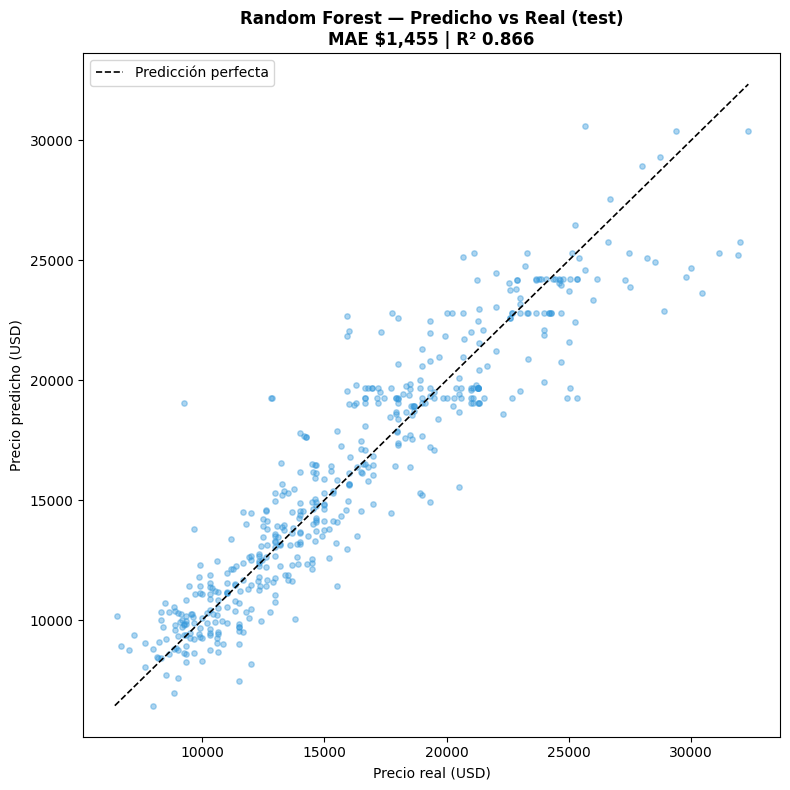

Gráfico guardado.


In [3]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print(f"Random Forest (300 árboles)")
print(f"  MAE  test: ${mae_rf:,.0f} USD")
print(f"  RMSE test: ${rmse_rf:,.0f} USD")
print(f"  R²   test: {r2_rf:.3f}")
print(f"\nMejora vs baseline: MAE {mae_lr:,.0f} → {mae_rf:,.0f} USD ({(1-mae_rf/mae_lr)*100:.0f}% menos error)")

# Gráfico predicho vs real
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, pred_rf, alpha=0.4, s=15, color="#3498db")
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
ax.plot(lims, lims, "k--", linewidth=1.2, label="Predicción perfecta")
ax.set_xlabel("Precio real (USD)")
ax.set_ylabel("Precio predicho (USD)")
ax.set_title(f"Random Forest — Predicho vs Real (test)\nMAE ${mae_rf:,.0f} | R² {r2_rf:.3f}",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/06_pred_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Comparación de modelos

| Modelo | MAE test | R² test |
|---|---|---|
| Regresión lineal (baseline) | $1.682 USD | 0,836 |
| Random Forest (300 árboles) | **$1.455 USD** | **0,866** |

El Random Forest reduce el error absoluto medio un **14%** y explica el 86,6%
de la varianza de precios. La mejora es real pero no abrumadora: la relación
precio-año-km es *mayormente* lineal en este rango, y la regresión ya captura
bastante. Donde el bosque gana es en los extremos — autos casi 0km y autos con
kilometraje muy alto, donde la depreciación deja de ser lineal.

Un MAE de ~$1.455 sobre precios de $8.000-$23.000 significa un error típico
del 7-15% del valor del auto — suficiente para detectar desvíos groseros de
precio (gangas o sobreprecios), no para tasar al dólar exacto.

### Feature importance

¿Qué variables usa el Random Forest para decidir el precio? La importancia de
cada feature mide cuánto contribuye a reducir el error en los árboles del
bosque. Es diagnóstico, no causal — pero sirve para verificar que el modelo
aprendió algo razonable y no un artefacto.

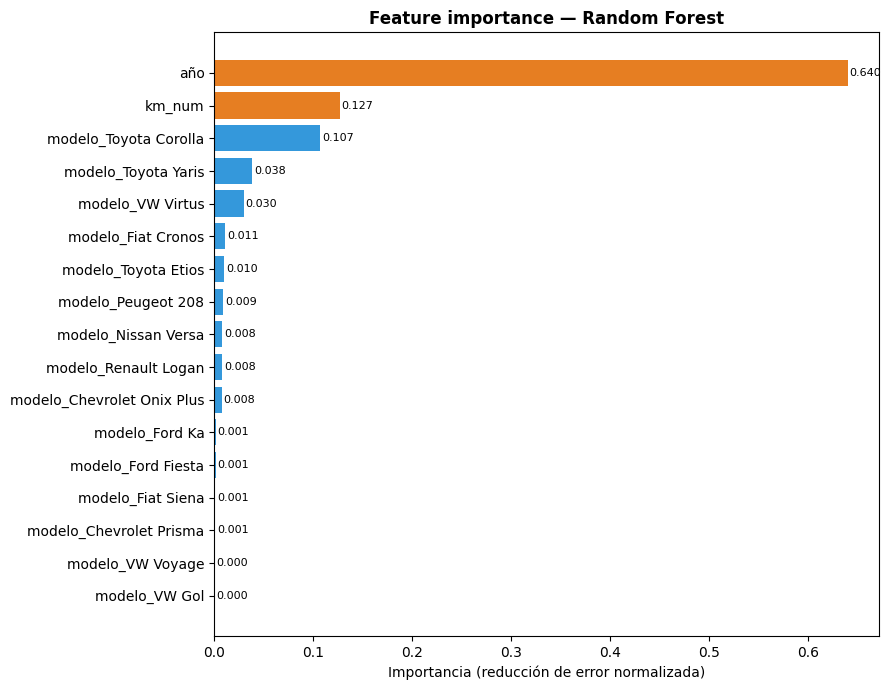

Gráfico guardado.
año                      0.6402
km_num                   0.1268
modelo_Toyota Corolla    0.1067
modelo_Toyota Yaris      0.0382
modelo_VW Virtus         0.0298
modelo_Fiat Cronos       0.0109
modelo_Toyota Etios      0.0099
modelo_Peugeot 208       0.0087


In [4]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colores = ["#e67e22" if f in ("año", "km_num") else "#3498db" for f in importancias.index]
ax.barh(importancias.index, importancias.values, color=colores)
ax.set_xlabel("Importancia (reducción de error normalizada)")
ax.set_title("Feature importance — Random Forest", fontweight="bold")
for i, v in enumerate(importancias.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")
print(importancias.sort_values(ascending=False).head(8).round(4).to_string())

### Interpretación de las importancias

Tal como era esperable, **año (0,64) y km (0,13) dominan**: juntos explican
más de tres cuartos de las decisiones del bosque. El precio de un usado es,
ante todo, una función de su antigüedad y uso — la marca importa menos de lo
que el marketing sugiere.

De las dummies de modelo, solo tres pesan de forma apreciable:

- **Toyota Corolla (0,11):** es un segmento distinto (sedán mediano) al resto
  del dataset (segmento B); el bosque necesita la dummy para ajustar su precio
  sistemáticamente más alto.
- **Toyota Yaris (0,04) y VW Virtus (0,03):** modelos con prima de precio
  sobre el resto a igualdad de año/km.

El resto de las dummies aporta casi nada: dentro del segmento B, a igualdad de
año y km, los precios son notablemente parecidos entre marcas. Esto refuerza el
hallazgo de los notebooks anteriores: **la rentabilidad no se define por elegir
"la marca correcta" sino por comprar barato y operar barato.**

### Detección de oportunidades de compra

Predigo el precio de **todas** las publicaciones del dataset y calculo el
**residuo** (precio real − precio predicho). Un residuo muy negativo significa
que la publicación está mucho más barata de lo que sus características
justifican — un candidato a ganga.

⚠️ **Advertencia importante:** un precio muy por debajo del predicho puede ser
una ganga, pero también puede indicar problemas que el modelo no observa:
auto chocado y reparado, deudas de patente, problemas de papeles, o
directamente una publicación fraudulenta. El precio bajo *es información* — el
mercado rara vez regala plata. Esta lista señala **candidatos a investigar en
persona**, no compras seguras.

In [5]:
df_op = df.copy()
df_op["precio_predicho"] = rf.predict(X)
df_op["residuo_usd"] = df_op["precio_usd"] - df_op["precio_predicho"]
df_op["residuo_pct"] = df_op["residuo_usd"] / df_op["precio_predicho"] * 100

oportunidades = df_op.nsmallest(15, "residuo_pct")[
    ["modelo", "año", "km_num", "precio_usd", "precio_predicho", "residuo_usd", "residuo_pct"]
].rename(columns={
    "km_num": "km", "precio_usd": "precio_real",
})

print("Top 15 publicaciones más baratas de lo que el modelo predice:")
print(oportunidades.round(0).to_string(index=False))

Top 15 publicaciones más baratas de lo que el modelo predice:
       modelo  año       km  precio_real  precio_predicho  residuo_usd  residuo_pct
  Fiat Cronos 2027      0.0       2500.0           5793.0      -3293.0        -57.0
  Fiat Cronos 2027      0.0       2500.0           5793.0      -3293.0        -57.0
  Fiat Cronos 2027      0.0       2500.0           5793.0      -3293.0        -57.0
  Fiat Cronos 2027      0.0       2500.0           5793.0      -3293.0        -57.0
  Fiat Cronos 2027      0.0       2500.0           5793.0      -3293.0        -57.0
  Fiat Cronos 2027      0.0       2500.0           5793.0      -3293.0        -57.0
  Fiat Cronos 2025      0.0       9267.0          19057.0      -9790.0        -51.0
  Fiat Cronos 2027      0.0       3333.0           5793.0      -2460.0        -42.0
  Fiat Cronos 2027      0.0       3333.0           5793.0      -2460.0        -42.0
  Fiat Cronos 2027      0.0       3333.0           5793.0      -2460.0        -42.0
  Fiat Cronos 

### Depreciación proyectada a 3 años de uso Cabify

Para cada modelo tomo su **auto mediano actual** (año, km y precio medianos) y
lo proyecto 3 años al futuro con uso intensivo de Cabify: **+3 años de
antigüedad y +100.000 km** (~150 km/día × 26 días × 36 meses ≈ 140.000 km;
uso 100.000 como escenario moderado). El Random Forest predice cuánto valdría
ese auto, y la diferencia es la **depreciación esperada** del período.

⚠️ **Limitación:** para los modelos más nuevos (Cronos, Onix Plus, año mediano
2025) la proyección cae **fuera del rango de entrenamiento** — no hay Cronos
2028 en el dataset. El Random Forest no extrapola: predice con los autos más
parecidos que vio, por lo que la depreciación de los modelos nuevos está
probablemente **subestimada o distorsionada**. Tomar esos valores con pinzas.

In [6]:
proyecciones = []
for modelo in sorted(df["modelo"].unique()):
    sub = df[df["modelo"] == modelo]
    año_med = int(sub["año"].median())
    km_med = sub["km_num"].median()
    precio_med = sub["precio_usd"].median()

    # Armar el vector de features del auto proyectado (+3 años, +100.000 km)
    fila = pd.DataFrame([{c: 0 for c in X.columns}])
    fila["año"] = año_med          # el año de fabricación no cambia...
    fila["km_num"] = km_med + 100_000
    fila[f"modelo_{modelo}"] = 1
    # ...pero la antigüedad sí: un auto de 2020 en 2029 "vale como" uno de 2017 hoy.
    # Lo capturo restando 3 al año de fabricación relativo al mercado actual.
    fila["año"] = año_med - 3

    precio_futuro = rf.predict(fila)[0]
    dep_usd = precio_med - precio_futuro
    dep_pct = dep_usd / precio_med * 100
    proyecciones.append({
        "modelo": modelo, "año_mediano": año_med, "km_medianos": km_med,
        "precio_actual": precio_med, "precio_proyectado": precio_futuro,
        "depreciacion_usd": dep_usd, "depreciacion_pct": dep_pct,
    })

df_dep = pd.DataFrame(proyecciones).sort_values("depreciacion_pct")
print("Depreciación proyectada a 3 años / +100.000 km (ordenado: retiene más valor primero):")
print(df_dep.round(0).to_string(index=False))

Depreciación proyectada a 3 años / +100.000 km (ordenado: retiene más valor primero):
             modelo  año_mediano  km_medianos  precio_actual  precio_proyectado  depreciacion_usd  depreciacion_pct
          VW Virtus         2021      60000.0        15850.0            14058.0            1792.0              11.0
          VW Voyage         2017     110000.0         9867.0             8588.0            1278.0              13.0
   Chevrolet Prisma         2018     110000.0         9933.0             8584.0            1349.0              14.0
         Fiat Siena         2016     124500.0         8653.0             7150.0            1504.0              17.0
       Toyota Yaris         2023      36000.0        20667.0            16949.0            3718.0              18.0
            Ford Ka         2018      85000.0        10633.0             8579.0            2054.0              19.0
        Ford Fiesta         2017      98000.0        11500.0             9158.0            2342.0     

### Interpretación de la depreciación proyectada

**Los que mejor retienen valor** en la proyección son el **VW Virtus (11%)**,
**VW Voyage (13%)**, **Chevrolet Prisma (14%)** y **Fiat Siena (17%)**. Hay dos
razones distintas mezcladas:

- Voyage, Prisma y Siena ya son autos viejos con mucho km: la mayor parte de su
  depreciación **ya ocurrió**. Un Siena 2016 con 124.500 km está cerca del piso
  de precio del mercado — 100.000 km más lo mueven poco. Esto es una excelente
  noticia para el caso Cabify: el auto más rentable de operar (Siena) es además
  uno de los que menos valor pierde.
- El Virtus retiene valor por prima de marca/demanda en el mercado de usados.

**Los que más se deprecian** son el **Nissan Versa (32%)**, **Renault Logan
(27%)** y **Peugeot 208 (26%)** — autos de gama media que todavía tienen valor
por perder y marcas con menos demanda de reventa.

**Lectura combinada con la rentabilidad (notebooks 03-05):** en 3 años, un
Fiat Siena genera ~$626 USD/mes de ganancia operativa (~$22.500 acumulados) y
pierde ~$1.500 de valor → resultado neto ampliamente positivo. Un Toyota
Corolla pierde ~$5.000 de valor **y además** opera a pérdida — destruye valor
por ambas puntas.

**Advertencia de extrapolación:** los valores de Fiat Cronos y Chevrolet Onix
Plus (año mediano 2025, km 0) son los menos confiables — proyectarlos a 2028
con 100.000 km cae fuera del rango de datos y el Random Forest no extrapola,
por lo que su depreciación real de "primeros 100.000 km" (la más empinada de
la vida del auto) está probablemente **subestimada**.

---

## Conclusiones del análisis de ML

### Métricas

- **Regresión lineal (baseline):** MAE $1.682 USD, R² 0,836
- **Random Forest:** MAE $1.455 USD, RMSE $1.999 USD, R² 0,866 — 14% menos
  error que el baseline. Año y km explican >75% de la importancia.

### Oportunidades de compra

El detector de residuos funcionó, pero enseñó una lección de datos reales: las
15 publicaciones "más baratas de lo esperado" están dominadas por **Fiat Cronos
2027 0km a $2.500-3.300** — que no son gangas sino **anticipos de planes de
ahorro** (se paga el resto en cuotas). Es exactamente el tipo de falso positivo
que anticipaba la advertencia: el precio publicado no siempre es el precio
total. El candidato genuino más interesante de la lista es un **Renault Logan
2016 con 141.500 km a $6.533** (36% bajo lo predicho) — un auto GNC del top 5
de rentabilidad, aunque el descuento amerita revisión mecánica y de papeles.

### Depreciación y rentabilidad total

La proyección a 3 años/+100.000 km completa la ecuación del proyecto:

> **Rentabilidad total = ganancia operativa mensual acumulada − depreciación del período**

El **Fiat Siena** gana por ambas puntas: máxima ganancia operativa (~$626
USD/mes con el modelo v2) y depreciación baja (~$1.500 USD en 3 años, porque
ya está cerca de su piso de precio). En el otro extremo, el **Toyota Corolla**
pierde por ambas: opera a pérdida (-$151 USD/mes) y encima se deprecia ~$5.000.

### Mejoras pendientes

- Filtrar publicaciones de planes de ahorro antes de entrenar (título con
  "plan", "cuota", "anticipo") — hoy contaminan tanto el entrenamiento como
  el detector de gangas.
- Features adicionales: versión/motorización (parseable del título), GNC.
- Validación cruzada por modelo para medir el error por segmento.
- Integrar el predictor al dashboard: que el usuario cargue año/km/precio de
  una publicación real y reciba tasación + alerta de sobreprecio.

### Persistencia del modelo

Guardo el Random Forest entrenado en `models/` con joblib para poder usarlo
desde el dashboard u otros scripts sin re-entrenar. El binario no se commitea
(está en `.gitignore`) — se regenera ejecutando este notebook.

In [7]:
import joblib, os

os.makedirs("../models", exist_ok=True)
ruta = "../models/rf_precios.joblib"
joblib.dump(rf, ruta)
print(f"Modelo guardado en {ruta} ({os.path.getsize(ruta)/1e6:.1f} MB)")

Modelo guardado en ../models/rf_precios.joblib (39.6 MB)
